<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/IT%E4%BC%81%E6%A5%AD%E3%81%AE%E9%80%80%E8%81%B7%E8%80%85%E4%BA%88%E6%B8%AC%EF%BC%88%E8%AC%9B%E5%B8%AB%E3%82%B3%E3%83%BC%E3%83%87%E3%82%A3%E3%83%B3%E3%82%B0%E4%BE%8B%EF%BC%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSVファイルの取得

In [ ]:
!pip install gdown

import gdown

# ファイルIDとダウンロード先パス
file_id = "1Hf7Uy8OrrKrgSo4qP7BMeHDxWCmKE2Kt"
output = "sample_data/hr.csv"

# ダウンロード
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Hf7Uy8OrrKrgSo4qP7BMeHDxWCmKE2Kt
To: /content/sample_data/hr.csv
100%|██████████| 228k/228k [00:00<00:00, 67.5MB/s]


'sample_data/hr.csv'

# ライブラリのインポート

In [ ]:
#データ分析/データ可視化ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#機械学習ライブラリ　LightGBM
import lightgbm as lgb

#機械学習ライブラリ　sklearn ユーティリティ
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#不均衡データの少数派データを増やすオーバサンプリング手法 SMOTE
from imblearn.over_sampling import SMOTE

#データフレームが全列表示されるように設定
pd.set_option('display.max_columns', None)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


#１．データの読み込み

In [ ]:
data_path = 'sample_data/hr.csv'  # アップロードされたファイルのパス
data = pd.read_csv(data_path)

データの基本情報を確認

In [ ]:
print("データの基本情報:")
print(data.info())

データの基本情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel      

データフレーム内の確認

In [ ]:
#確認
data.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0


#２．データの前処理

欠損値の確認用関数の作成

In [ ]:
# 欠損値の確認用関数の作成（別の処理でも必要になる可能性を考慮し、今回は準備）
def handle_missing_values(df):
    print("欠損値の合計:")
    print(df.isnull().sum())
    return df.dropna()

欠損値の確認

In [ ]:
data = handle_missing_values(data)

欠損値の合計:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
Ye

#３．カテゴリカルデータを数値に変換<br>
（今回、ランダムフォレストを利用するのでラベルエンコーディングを利用）

分類モデルにおけるカテゴリカルデータの数値変換の判断基準例<br>
●モデルの種類で判断<br>
決定木ベース（ランダムフォレスト、XGBoostなど） → ラベルエンコーディング。<br>
線形モデル、SVM、ニューラルネットワーク → ダミー変数化。<br>
<br>
●カテゴリ数で判断<br>
種類が多い → ラベルエンコーディング（次元削減）。<br>
種類が少ない → ダミー変数化。<br>
<br>
●データの意味で判断<br>
順序がある → ラベルエンコーディング。<br>
順序がない → ダミー変数化。<br>
<br>
●注意点<br>
ラベルエンコーディングの誤解を避ける<br>
順序がないデータでラベルエンコーディングを使うと、モデルが誤解する可能性があります。<br>
例: 「赤=0, 青=1, 緑=2」→ 青が赤と緑の中間値と解釈される。<br>
<br>
高次元問題の影響<br>
ダミー変数化では次元が増えるため、大量のカテゴリがある場合は計算コストが高くなる点に注意。<br>

In [ ]:
# カテゴリカルデータをラベルエンコーディング
label_encoders = {}

#元データを保持するため、新しい変数を準備
data_cr=data

for column in data_cr.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data_cr[column] = le.fit_transform(data_cr[column])
    label_encoders[column] = le

In [ ]:
#データの確認
print(data_cr.head(1))

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   

   Education  EducationField  EmployeeCount  EmployeeNumber  \
0          2               1              1               1   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  \
0                        2       0          94               3         2   

   JobRole  JobSatisfaction  MaritalStatus  MonthlyIncome  MonthlyRate  \
0        7                4              2           5993        19479   

   NumCompaniesWorked  Over18  OverTime  PercentSalaryHike  PerformanceRating  \
0                   8       0         1                 11                  3   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                 0   

   TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  \
0                  8                      

特徴量の選別<br>
相関関係が目的変数と特徴量の関係を見渡し易いため、まずは相関を可視化する。

<Axes: >

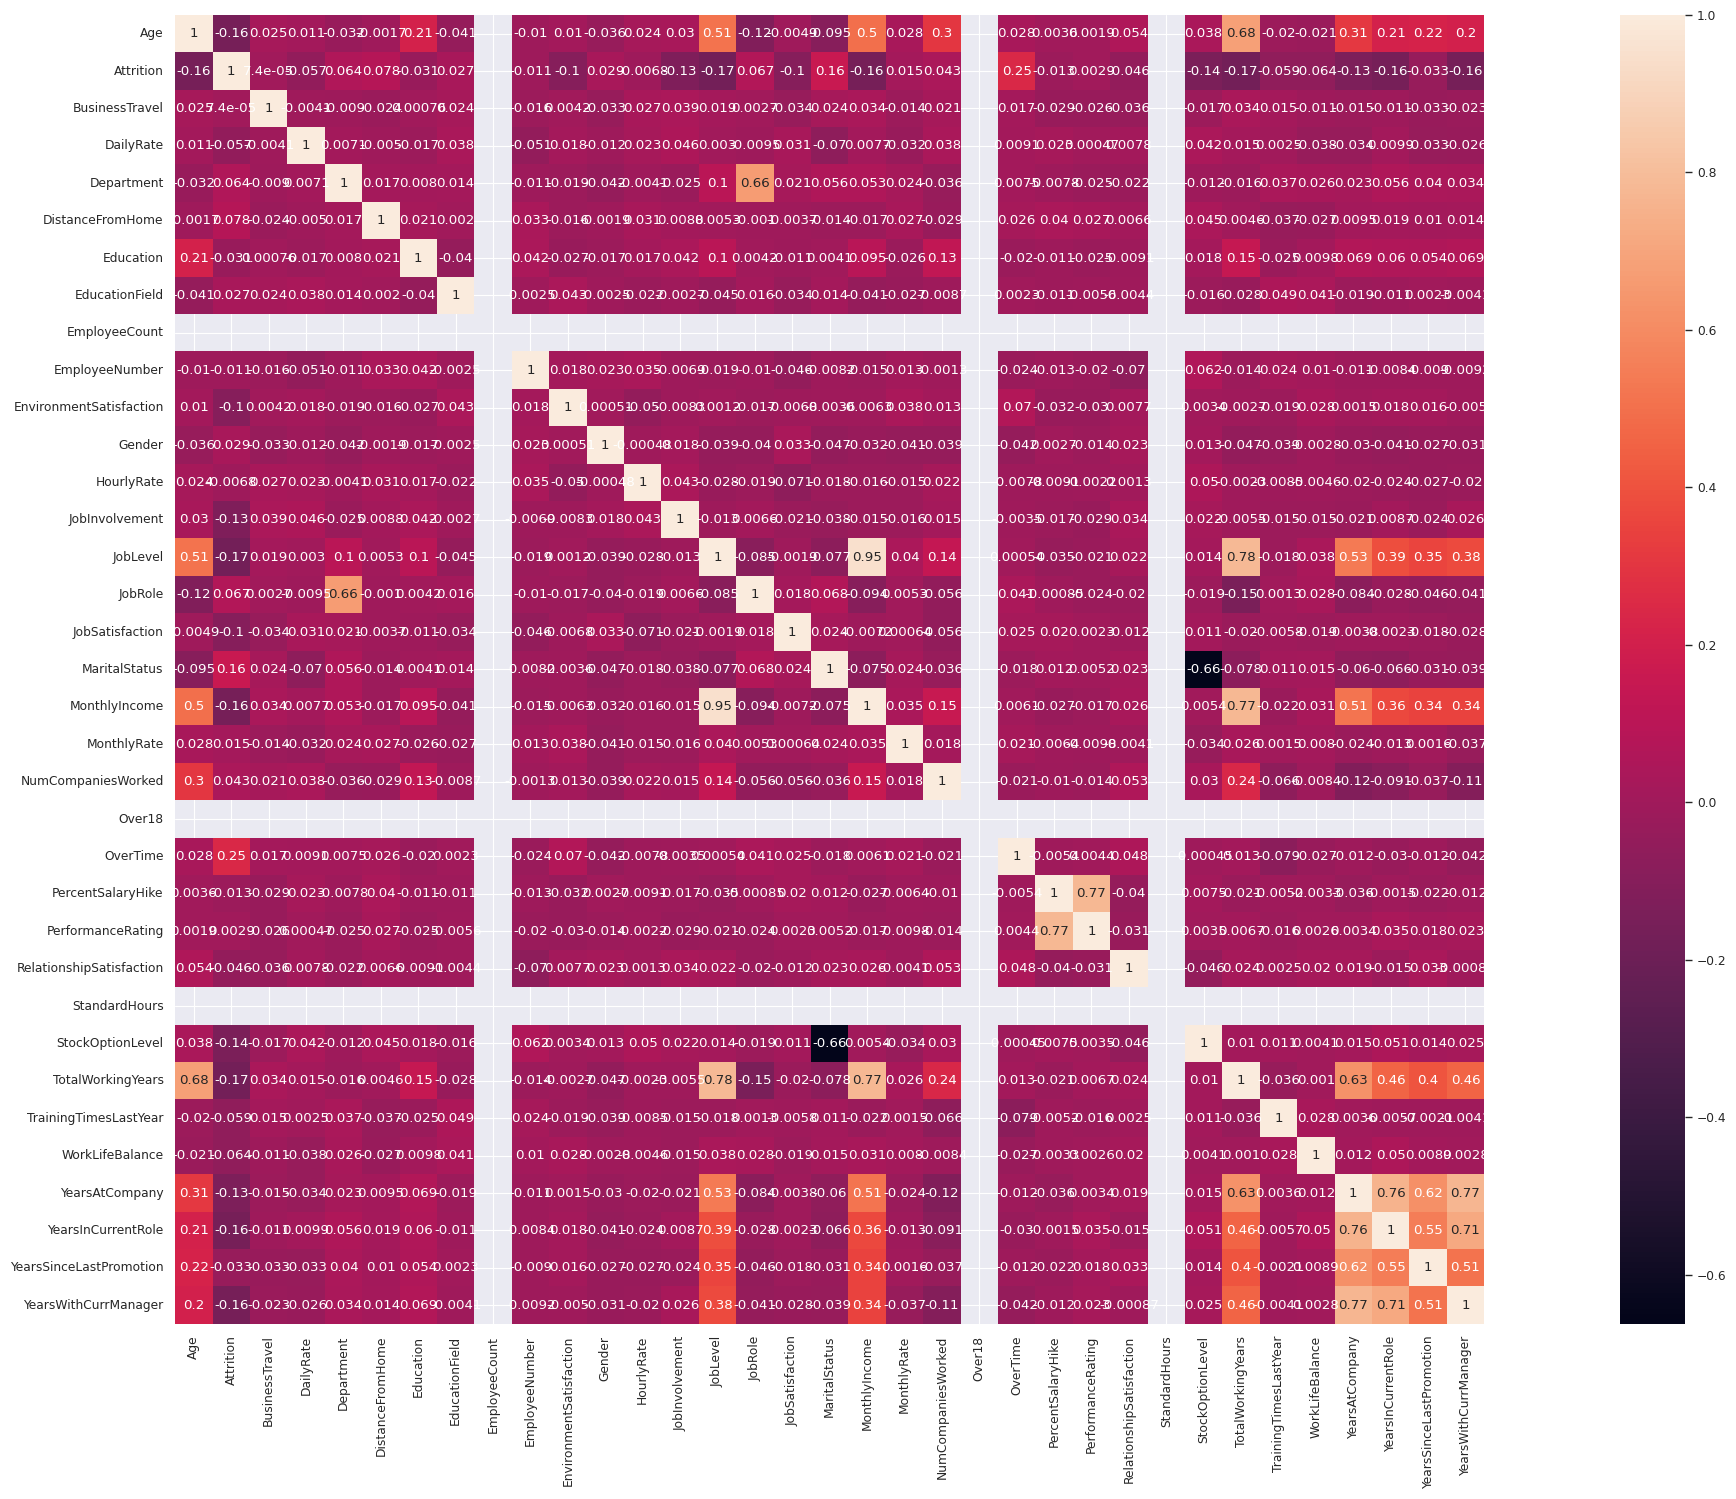

In [ ]:
#pandas(pd)のcorrメソッドで相関係数を求める
cor_mat= data_cr.corr()

#グラフ設定
fig=plt.gcf()
fig.set_size_inches(35,17)

#seaborn可視化設定
sns.set(font_scale=0.1)
sns.set_context('paper')
sns.heatmap(data=cor_mat,square=True,annot=True,cbar=True)

データ量が多すぎるため、この段階では特徴量の選別は諦める。<br>
一度、モデルを作成したのちに特徴量の重要度を再度、考える。

#４．特徴量と目的変数の分離

In [ ]:
# 目的変数を分離
target_column = 'Attrition'  # 目的変数の列名を指定
if target_column in data_cr.columns:
    y = data_cr[target_column]
    X = data_cr.drop(target_column, axis=1)
else:
    raise ValueError(f"目的変数 '{target_column}' がデータに含まれていません！")

In [ ]:
#特徴量の確認
print(X.head(1))

   Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
0   41               2       1102           2                 1          2   

   EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  \
0               1              1               1                        2   

   Gender  HourlyRate  JobInvolvement  JobLevel  JobRole  JobSatisfaction  \
0       0          94               3         2        7                4   

   MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked  Over18  \
0              2           5993        19479                   8       0   

   OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  \
0         1                 11                  3                         1   

   StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  \
0             80                 0                  8                      0   

   WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  \
0 

#５．標準化をするかどうか

今回は分類モデルとなります。<br>
また、モデルとしては使いやすい決定木の一つである、ランダムフォレストを利用しようと思います。<br>
決定木を利用する場合、スケーリングは不要となるため標準化は実施しなくても問題ありません。<br>
そのため、今回は標準化を行わずに作業を進めます。<br>
理由：決定木のアルゴリズムが各特徴量の大小関係しか見ないためです。（決定木が特徴量の数値の大小関係(順位)だけを見ていて、数値にどの程度の差があるかを見ていないため）<br>

今後、別モデルを利用することを考慮するのであれば、このタイミングで標準化を行っても良いかと思います。

#６．データの分割

In [ ]:
#データの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#７．モデルの作成

In [ ]:
#モデルの作成
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#８．モデルの評価

In [ ]:
#モデルの評価
predictions = model.predict(X_test)


In [ ]:
#結果確認
print("\n混同行列:")
print(confusion_matrix(y_test, predictions))

print("\n分類レポート:")
print(classification_report(y_test, predictions))

print("\n正解率:")
print(accuracy_score(y_test, predictions))

#追加（分類レポート内でも表示しているが、見易さのために別途出力）
# 適合率、再現率、F値の出力
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("\n適合率 (Precision):", precision)
print("再現率 (Recall):", recall)
print("F値 (F1-Score):", f1)


混同行列:
[[251   4]
 [ 35   4]]

分類レポート:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294


正解率:
0.8673469387755102

適合率 (Precision): 0.5
再現率 (Recall): 0.10256410256410256
F値 (F1-Score): 0.1702127659574468


#９．結果について

●混同行列<br>
[[251, 4], [35, 4]] の意味：<br>
0 (退職しない) を正しく予測した数: 251<br>
0 を 1 (退職する) と誤って予測した数: 4<br>
1 を 0 (退職しない) と誤って予測した数: 35<br>
1 を正しく予測した数: 4<br>
→ クラス 1 (退職する) の予測が非常に難しいことを示しています。<br>
<br>
●分類レポート（4つの指標を見やすくするために表示しました）<br>
クラス 1 の precision（適合率）は 0.50、recall（再現率）は 0.10。<br>
適合率: 退職すると予測したうち実際に退職した割合。<br>
再現率: 実際に退職した人のうちモデルが正しく予測できた割合。<br>
「実際に退職した中で、正しく退職と予測した割合」<br>
クラス1の再現率は0.10と非常に低い。<br>
退職者のうち10%しか正しく予測できていない。<br>
F1スコア (F1-Score):<br>
適合率と再現率の調和平均で、クラス1は0.17。<br>
再現率が低いためF1スコアも低い。<br>
クラス 0 の precision や recall は高い（どちらも 0.88 以上）。<br>
<br>
●正解率<br>
全体の正解率は 86.7% と高いように見えますが、クラス 0 に偏った結果であるため注意が必要です。<br>
マクロ平均と加重平均<br>
マクロ平均 (macro avg) は全体のバランスが悪い（f1-score は 0.55）。<br>
加重平均 (weighted avg) は正解率に近い値（0.83）で、クラス 0 の影響が大きい。<br>

●結論<br>
問題点: クラス 1（退職する）の予測がうまくいっていない。<br>
原因:<br>
データが不均衡（クラス 0 のサンプルが多い）。<br>
モデルがクラス 1 を過小評価している。<br>

#１０．この結果を踏まえて、どのように改善していくか

●特徴量の再検証<br>
特徴量の再検証を行い、不要なデータの削除、特徴量の追加などを視野に入れる<br>
<br>
●データの不均衡への対応<br>
クラス 1 を増やすためのオーバーサンプリング（SMOTEなど）。<br>
クラス 0 を減らすためのアンダーサンプリング。<br>
<br>
●モデルのチューニング<br>
class_weight='balanced' をランダムフォレストに追加など。<br>
<br>
●評価指標を変更<br>
ROC-AUC スコアなど、クラスの不均衡に強い指標を使用。<br>
<br>
●別モデルの作成<br>

# 例：特徴量を選別する方法<br>
<br>
特徴量の重要度を利用する<br>
ランダムフォレストにおける、特徴量の重要度の計算方法<br>
ランダムフォレストでは、特徴量の重要度は次の手順で計算されます。<br>
●ジニ不純度やエントロピーの減少:<br>
各特徴量がモデルの予測に使用された際に、不純度（ジニ不純度やエントロピー）がどれだけ減少したかを計算します。<br>
この減少量の合計がその特徴量の重要度になります。<br>
<br>
●全ての決定木で平均化:<br>
ランダムフォレストは複数の決定木を使用します。それぞれの木で得られた特徴量の重要度を平均化します。<br>
<br>
●正規化:<br>
重要度の合計が1になるように正規化されます。<br>

In [ ]:
# 特徴量の重要度を表示
importances = model.feature_importances_ #モデルに学習された特徴量ごとの重要度を取得します。
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances}) #各特徴量とその重要度をデータフレーム形式で整列します。
feature_importance.sort_values(by='Importance', ascending=False, inplace=True) #重要度の高い順に並べ替えます。
print("\n特徴量の重要度:")
print(feature_importance)


特徴量の重要度:
                     Feature  Importance
17             MonthlyIncome    0.074968
21                  OverTime    0.064823
0                        Age    0.056865
2                  DailyRate    0.050505
27         TotalWorkingYears    0.048104
18               MonthlyRate    0.047090
8             EmployeeNumber    0.045296
11                HourlyRate    0.043352
4           DistanceFromHome    0.042012
30            YearsAtCompany    0.041914
19        NumCompaniesWorked    0.036035
14                   JobRole    0.032731
22         PercentSalaryHike    0.032530
26          StockOptionLevel    0.031840
33      YearsWithCurrManager    0.028512
31        YearsInCurrentRole    0.027299
13                  JobLevel    0.026893
32   YearsSinceLastPromotion    0.026549
28     TrainingTimesLastYear    0.025413
15           JobSatisfaction    0.025368
16             MaritalStatus    0.025151
9    EnvironmentSatisfaction    0.024602
6             EducationField    0.023972
12    

●高い重要度を持つ特徴量:<br>
MonthlyIncome: 予測に最も影響を与えている特徴量。<br>
特徴量の重要度が高いほど、モデルの予測に大きく寄与しています。<br>
<br>
●低い重要度を持つ特徴量:<br>
比較的予測に影響を与えていない特徴量。<br>
これらはデータやドメイン知識に基づき削除を検討することもできます。<br>
<br>
●特徴量の重要度を活用する方法<br>
モデル改善:<br>
重要度が低い特徴量を削除することでモデルの過学習を防ぎ、計算効率を上げることができます。<br>
<br>
ビジネスインサイト:<br>
どの要因が退職に最も影響しているかを特定できます。<br>
例えば、OverTime の重要度が高い場合、残業が退職リスクに大きく影響している可能性があります。<br>
<br>
これらの判別を行った後、統計量の確認、相関分析の実施、特徴量の分布確認、特徴量エンジニアリングを行う。<br>
<br>


上記の改善は復習用テキストを参考にして頂ければイメージができます。<br>
お時間がある際に取り組んでみて下さい。